# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d

torch.manual_seed(0)

device = 'cuda' ## TODO
torch.set_default_device(device)

### Define the boundary rectangles

In [2]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    bndry = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return bndry

pts_bndry = get_boundary_angled_rectangles()

bounds = torch.vstack([pts_bndry.min(0).values, pts_bndry.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_bndry.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [ ]:
from torch import nn
from torch import tanh, sin

class GeneralNet(nn.Module):
    def __init__(self, ks, act=tanh):
        super(GeneralNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.act = act

    def forward(self, x):
        x = self.fcs[0](x)
        for i in range(2,self.D+1):
            x = self.fcs[i-1](self.act(x))
        return x

In [10]:
from torch.func import vmap, jacrev, jacfwd, functional_call

model = GeneralNet(ks=[3, 32, 32, 1])

params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)

## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_laplacian_f = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
f_theta = jacrev(f, argnums=0)  # dict
vf_theta = vmap(f_theta, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
laplacian_phi = jacrev(laplacian_f, argnums=0) # dict
v_laplacian_phi = vmap(laplacian_phi, in_dims=(None, 0), out_dims=(0))

### Define mean curvature function

In [11]:
# def get_mean_curvature(F, H):
#     '''
#     Mean-curvature in D-dimensions
#     F: grad(f) gradients, shape [N,D]
#     H: hess(f) Hessian, shape [N,D,D]

#     https://u.math.biu.ac.il/~katzmik/goldman05.pdf
#     For a shape implicitly defined by f<0:
#     - div(F/|F|) = -(FHF^T - |F|^2 tr(H)) / 2*|F|^3
#     In <=3D we can expand the formula, if we want to validate https://www.archives-ouvertes.fr/hal-01486547/document
#     fx, fy, fz = F.T
#     fxx, fxy, fxz, fyx, fyy, fyz, fzx, fzy, fzz = H.flatten(start_dim=1).T
#     k = (fx*fx*(fyy+fzz) + fy*fy*(fxx+fzz) + fz*fz*(fxx+fyy) - 2*(fx*fy*fxy+fx*fz*fxz+fy*fz*fyz)) / (2*(fx*fx+fy*fy+fz*fz).pow(3/2))
#     '''
#     ## Quadratic form
#     FHFT = torch.einsum('bi,bij,bj->b', F, H, F)
#     ## Trace of Hessian
#     trH = torch.einsum('bii->b', H)
#     ## Norm of gradient
#     N = F.square().sum(1).sqrt()
#     ## Mean-curvature
#     mean_curvatures = -(FHFT - N.pow(2)*trH) / (2*N.pow(3))
#     return mean_curvatures

# def get_laplacian(H):
#     '''
#     Laplacian in D-dimensions
#     H: hess(f) Hessian, shape [N,D,D]
#     '''
#     ## Trace of Hessian
#     trH = torch.einsum('bii->b', H)
#     return trH

### Main training loop

  0%|          | 0/10000 [00:00<?, ?it/s]

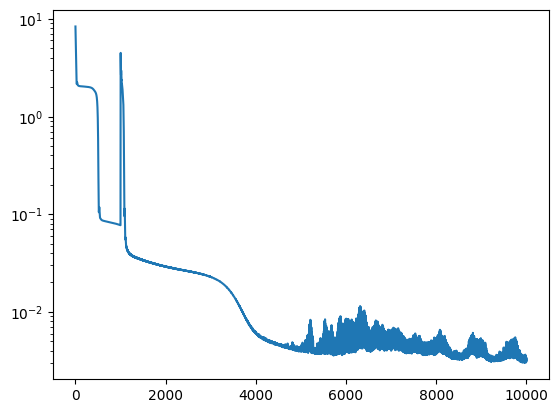

In [12]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

loss_over_iters = {}

for i in (pbar:=trange(10000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = f(params, pts_bndry).square().mean()
    loss_interface += 10*f(params, pts_corners).square().mean()
    
    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = (vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    ## 3) Mean curvature on the 0-surface
    if i<1000:
        # loss_curvature = torch.zeros([1,1])
        loss_laplacian = torch.zeros([1,1])
        pts = []
    else:
        ## Sample points on surface
        pts = torch.rand([10000, 3])
        vals_sq = model(pts).square().squeeze()
        pts = pts[vals_sq<1e-4]
        if len(pts):
            # Fs = vf_x(params, pts).squeeze(1)
            # Hs = vf_xx(params, pts).squeeze(1)
            # mean_curvatures = get_mean_curvature(Fs, Hs)
            # loss_curvature = mean_curvatures.square().mean()
            laplacian = v_laplacian_f(params, pts).squeeze(1)
            loss_laplacian = laplacian.square().mean()


    # loss = loss_interface + loss_eikonal + loss_curvature
    loss = loss_interface + loss_eikonal + loss_laplacian
    loss.backward(retain_graph=True)
    optim.step()

    pbar.set_description(f"interface: {loss_interface.item():.2e} "
                         f"eikonal: {loss_eikonal.item():.2e} "
                         # f"curvature: {loss_curvature.item():.2e} "
                         f"laplacian: {loss_laplacian.item():.2e} "
                         f"{len(pts)}"
                        )
    loss_over_iters[i] = loss.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

In [13]:
import sys
sys.path.append('..')
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [14]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

c:\Users\james\Desktop\Studium ETH\Master Thesis\GINN Code\ginn_env\lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [ ]:
# For future: leave out scaling via interface_length and surface_area because this isn't done for the loss either
def calculate_A_bndry(vf_theta, params, pts_bndry, interface_length=8):
    """
    Calculate the boundary integral matrix A_bndry.
    
    Args:
        vf_theta: Function mapping parameters and points to derivatives (jacobian).
        params: Model parameters as a dictionary.
        pts_bndry: Boundary points as a tensor of shape [n_points, n_dims].
        interface_length: Length of the interface for scaling (default: 8).
        
    Returns:
        torch.Tensor: Approximate Hessian of the boundary loss [n_params, n_params].
    """
    # Compute φ_i at boundary points
    phi_at_pts = vf_theta(params, pts_bndry)  # Returns a dict

    # Aggregate φ_i into a single tensor
    phi_at_pts_tensor = torch.cat([p.flatten(start_dim=1) for p in phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_bndry = torch.einsum('bi,bj->ij', phi_at_pts_tensor, phi_at_pts_tensor) * interface_length / len(pts_bndry)

    return A_bndry

def calculate_A_laplacian(v_laplacian_phi, params, pts, surface_area):
    """
    Calculate the Laplacian integral matrix A_laplacian.
    
    Args:
        vf_theta_lap: Function mapping parameters and points to Laplacians (second derivatives).
        params: Model parameters as a dictionary.
        pts: Surface points as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate Hessian of the laplacian loss [n_params, n_params].
    """
    
    # Compute Laplacians of φ_i at points
    lap_phi_at_pts = v_laplacian_phi(params, pts)  # Returns a dict
    
    # Aggregate Laplacians into a single tensor
    lap_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in lap_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_laplacian = torch.einsum('bi,bj->ij', lap_phi_tensor, lap_phi_tensor) * surface_area / len(pts_bndry)

    return A_laplacian

from scipy.spatial import Delaunay
def get_surface_area(pts):
    # Convert points to numpy array
    pts_np = pts.detach().cpu().numpy()

    # Perform Delaunay triangulation
    tri = Delaunay(pts_np)

    # Function to compute the area of a triangle given its vertices
    def triangle_area(v1, v2, v3):
        return 0.5 * np.linalg.norm(np.cross(v2 - v1, v3 - v1))

    # Compute the area of each triangle
    areas = np.array([triangle_area(pts_np[simplex[0]], pts_np[simplex[1]], pts_np[simplex[2]]) for simplex in tri.simplices])

    # Sum the areas to get the total surface area
    total_surface_area = areas.sum()

    return total_surface_area

In [55]:
A_bndry = calculate_A_bndry(vf_theta, params, pts_bndry, interface_length=8)

# Output the result
print("Interface integral matrix A_bndry:")
print(A_bndry)
print(torch.linalg.cond(A_bndry))
eigenvalues = torch.linalg.eigvals(A_bndry)
max_eigenvalue = torch.max(eigenvalues.real)  # Use .real to get the real part of the eigenvalues

print("Max eigenvalue:", max_eigenvalue)

# Define Laplacian integral matrix calculation
pts = torch.rand([10000, 3])
vals_sq = model(pts).square().squeeze()
pts = pts[vals_sq<1e-4]

A_laplacian = calculate_A_laplacian(v_laplacian_phi, params, pts, get_surface_area(pts))

# Output the result
print("Laplacian integral matrix A_laplacian:")
print(A_laplacian)
print(torch.linalg.cond(A_laplacian))
eigenvalues = torch.linalg.eigvals(A_laplacian)
max_eigenvalue = torch.max(eigenvalues.real)  # Use .real to get the real part of the eigenvalues

print("Max eigenvalue:", max_eigenvalue)

Interface integral matrix A_bndry:
tensor([[ 0.0565,  0.0203,  0.0437,  ..., -0.1583, -0.0968, -0.4519],
        [ 0.0203,  0.0406,  0.0422,  ..., -0.0200,  0.0244, -0.4216],
        [ 0.0437,  0.0422,  0.1129,  ..., -0.1736, -0.0127, -0.6581],
        ...,
        [-0.1583, -0.0200, -0.1736,  ...,  1.1477,  0.4854,  2.1309],
        [-0.0968,  0.0244, -0.0127,  ...,  0.4854,  0.3426,  0.6005],
        [-0.4519, -0.4216, -0.6581,  ...,  2.1309,  0.6005,  8.0000]],
       device='cuda:0', grad_fn=<DivBackward0>)
tensor(1.2706e+14, device='cuda:0', grad_fn=<SqueezeBackward1>)
Max eigenvalue: tensor(124.4294, device='cuda:0', grad_fn=<MaxBackward1>)
torch.Size([755, 1217])
torch.Size([755, 3])
Laplacian integral matrix A_laplacian:
tensor([[ 1.4987,  0.7370,  0.0268,  ..., -1.0999, -0.7423,  0.0000],
        [ 0.7370,  1.1423, -0.5980,  ..., -1.5610, -0.5235,  0.0000],
        [ 0.0268, -0.5980,  4.7436,  ...,  1.7916,  0.7559,  0.0000],
        ...,
        [-1.0999, -1.5610,  1.7916,  .